# Toy studies with $\gamma$
## Check for biases in combined LHCb and BESIII fit

### Turn off statistics box

In [1]:
gStyle->SetOptStat(0);

In [2]:
TH1D GammaHist("GammaHist", "", 50, 0.0, 180.0);
TH1D GammaErrHist("GammaErrHist", "", 50, 8.0, 40.0);
TH1D GammaPullHist("GammaPullHist", "", 50, -5.0, 5.0);
TH1D GammaLLHist("GammaLLHist", "", 50, 500.0, 900.0);

In [3]:
double Convergence = 0.0;
std::size_t NToys = 1000;
for(std::size_t i = 0; i < NToys; i++) {
    std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/";
    Filename += "ToyGammaFitResults_231218/";
    Filename += "Toy" + std::to_string(i) + ".root";
    TFile File(Filename.c_str(), "READ");
    TParameter<double> *LL = nullptr;
    File.GetObject("LL", LL);
    GammaLLHist.Fill(LL->GetVal());
    TParameter<int> *Status = nullptr, *CovStatus = nullptr;
    File.GetObject("Status", Status);
    File.GetObject("CovStatus", CovStatus);
    if(Status->GetVal() != 0 || CovStatus->GetVal() != 3) {
        continue;
    }
    Convergence += 1.0;
    std::vector<double> *FitValues = nullptr;
    File.GetObject("FitValues", FitValues);
    std::vector<double> *FitUncertainties = nullptr;
    File.GetObject("FitUncertainties", FitUncertainties);
    GammaHist.Fill((*FitValues)[19]);
    if((*FitValues)[19] < 85.0) {
        continue;
    }
    GammaPullHist.Fill(((*FitValues)[19] - 127.163)/(*FitUncertainties)[19]);
    GammaErrHist.Fill((*FitUncertainties)[19]*1.23);
}
Convergence /= NToys;
std::cout << "Fit convergence : " << Convergence << "\n";

Fit convergence : 0.943


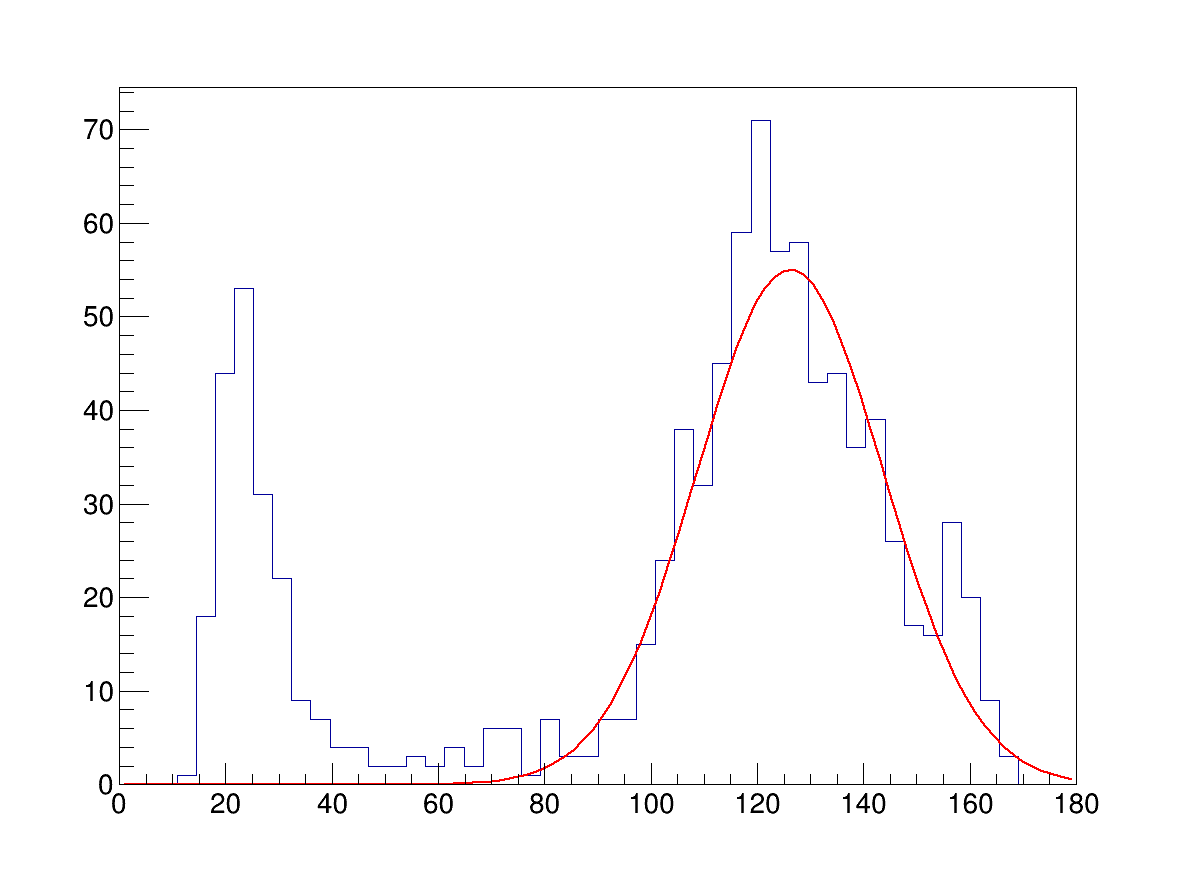

 FCN=260.398 FROM MIGRAD    STATUS=CONVERGED     143 CALLS         144 TOTAL
                     EDM=1.15951e-09    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     5.50126e+01   2.83505e+00   1.68132e-02  -6.06655e-06
   2  Mean         1.26268e+02   7.40965e-01   5.50236e-03   6.48506e-05
   3  Sigma        1.75542e+01   6.32744e-01   4.17206e-05  -2.20663e-03


In [4]:
TCanvas c1("c1", "", 1200, 900);
GammaHist.Draw();
GammaHist.Fit("gaus");
c1.Draw();

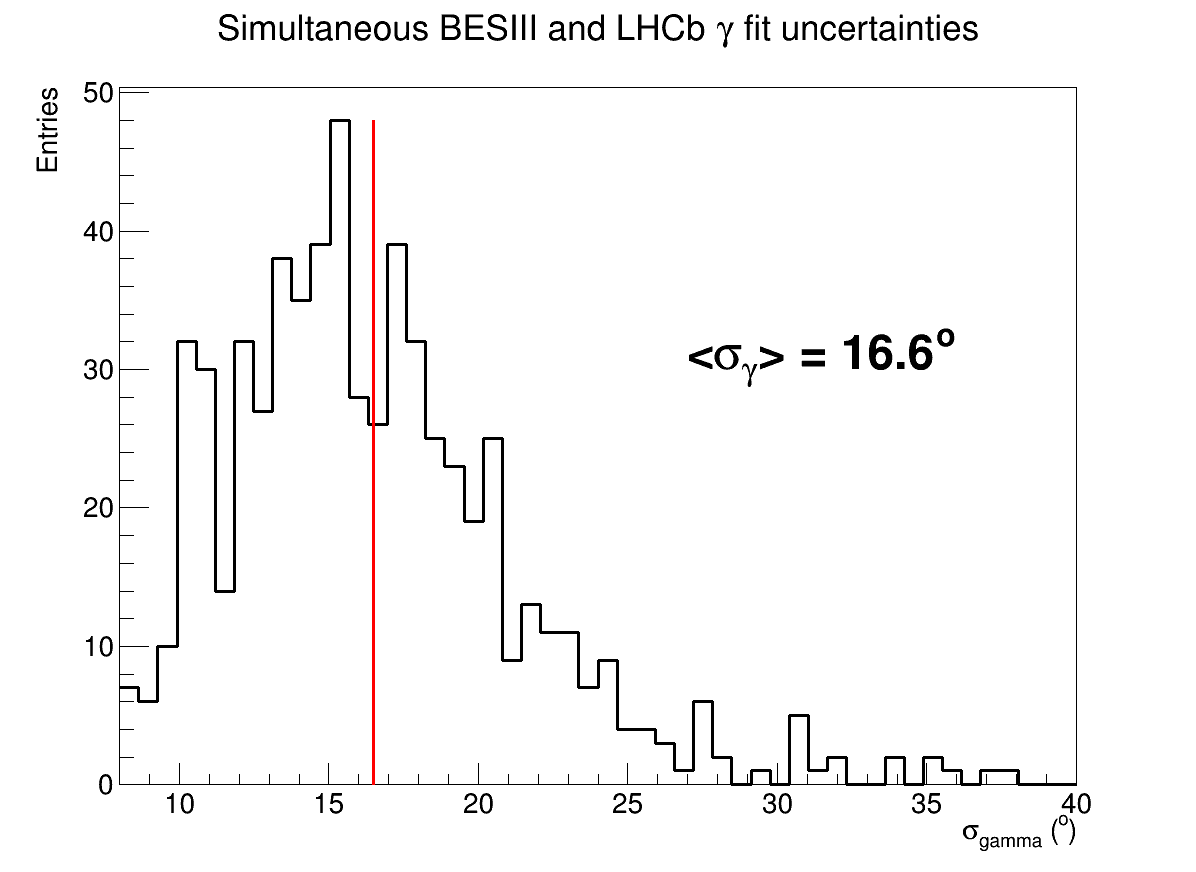

<sigma> = 16.4972


Info in <TCanvas::Print>: pdf file Gamma_SimultaneousFit_err.pdf has been created


In [5]:
TCanvas c2("c2", "", 1200, 900);
std::string Title = "Simultaneous BESIII and LHCb #gamma fit uncertainties";
Title += ";#sigma_{gamma} (^{o});Entries";
GammaErrHist.SetTitle(Title.c_str());
GammaErrHist.SetLineColor(kBlack);
GammaErrHist.SetLineWidth(3);
GammaErrHist.Draw();
TLine MeanLine(GammaErrHist.GetMean(), 0.0, GammaErrHist.GetMean(), GammaErrHist.GetMaximum());
MeanLine.SetLineWidth(3);
MeanLine.SetLineColor(kRed);
MeanLine.Draw("SAME");
TLatex latex;
latex.SetTextSize(0.06);
latex.DrawLatex(27.0, 30.0, "<#sigma_{#gamma}> = 16.6^{o}");
c2.Draw();
c2.SaveAs("Gamma_SimultaneousFit_err.pdf");
std::cout << "<sigma> = " << GammaErrHist.GetMean() << "\n";

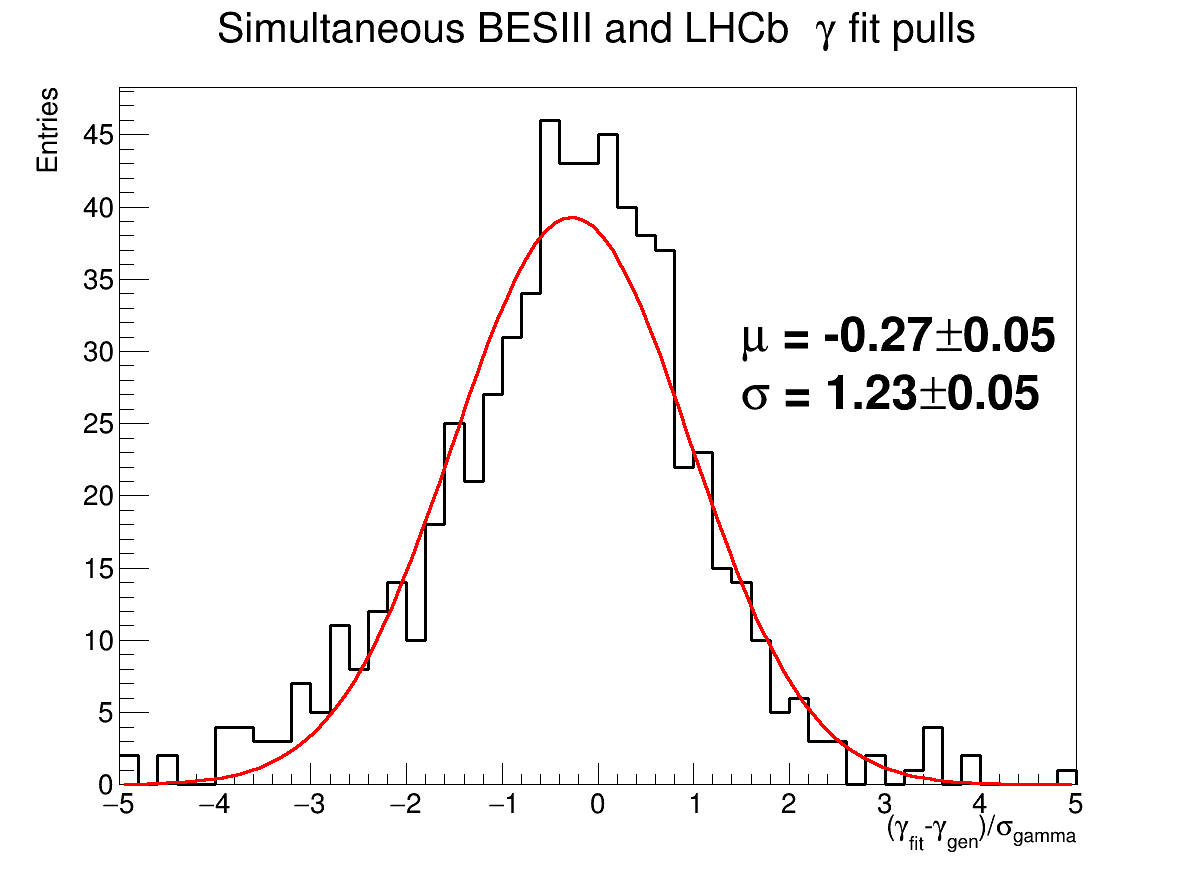

 FCN=40.9344 FROM MIGRAD    STATUS=CONVERGED      68 CALLS          69 TOTAL
                     EDM=1.18256e-09    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     3.92694e+01   2.26799e+00   5.05674e-03  -1.01120e-05
   2  Mean        -2.72456e-01   5.41520e-02   1.62443e-04  -5.91910e-04
   3  Sigma        1.23360e+00   5.26038e-02   2.91534e-05  -4.51822e-03


Info in <TCanvas::Print>: pdf file Gamma_SimultaneousFit_pull.pdf has been created


In [6]:
TCanvas c3("c3", "", 1200, 900);
std::string Title = "Simultaneous BESIII and LHCb #gamma fit pulls";
Title += ";(#gamma_{fit}-#gamma_{gen})/#sigma_{gamma};Entries";
GammaPullHist.SetTitle(Title.c_str());
GammaPullHist.SetLineColor(kBlack);
GammaPullHist.SetLineWidth(3);
GammaPullHist.Draw();
GammaPullHist.Fit("gaus", "O");
TF1 *f1 = GammaPullHist.GetFunction("gaus");
f1->SetLineWidth(3);
f1->Draw("SAME");
TLatex latex;
latex.SetTextSize(0.06);
latex.DrawLatex(1.5, 30.0, "#mu = -0.27#pm0.05");
latex.DrawLatex(1.5, 26.0, "#sigma = 1.23#pm0.05");
c3.Draw();
c3.SaveAs("Gamma_SimultaneousFit_pull.pdf");

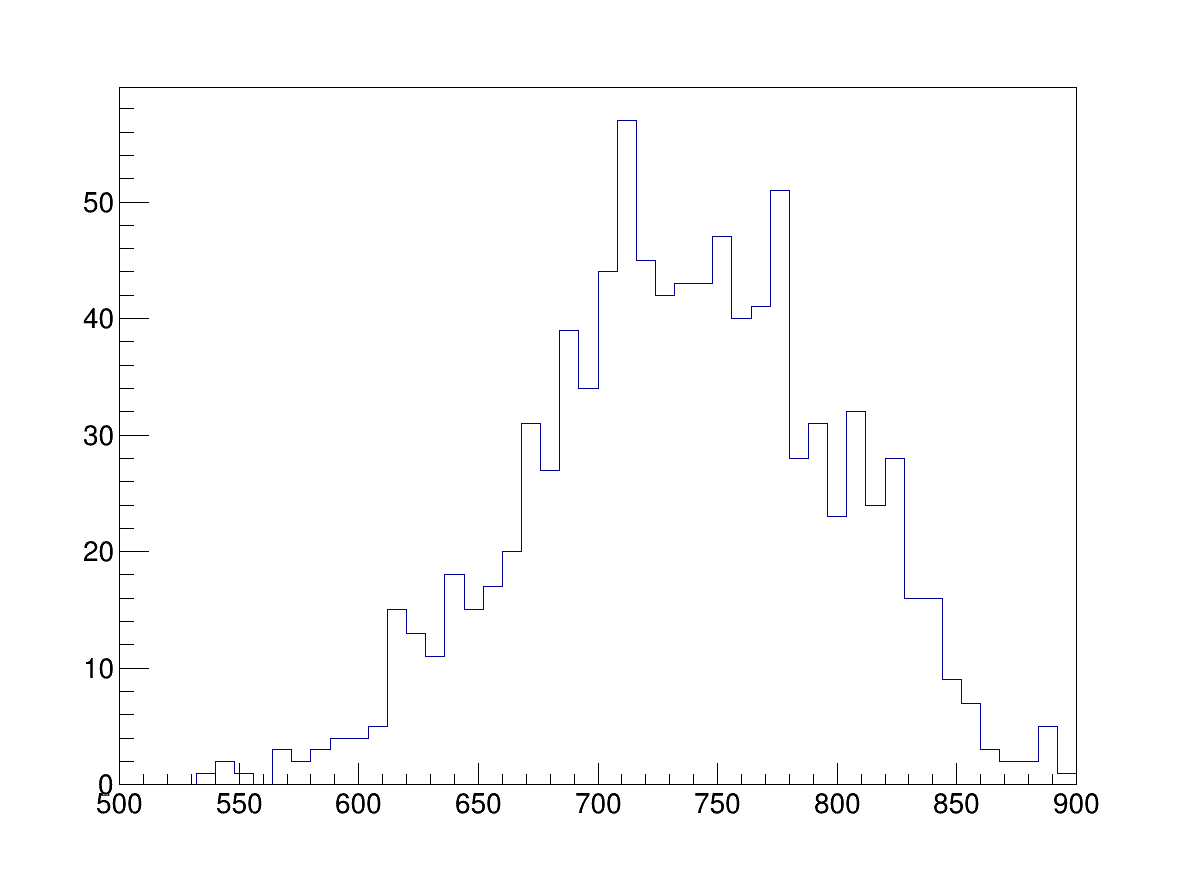

In [7]:
TCanvas c4("c4", "", 1200, 900);
GammaLLHist.Draw();
c4.Draw();